In [1]:
from CRNs import *
import numpy as np
import pickle
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
path = "/Users/csfloyd/Dropbox/Projects/GlycanAnalysis/Dirs/F_range_3_dim_grid_sm"

#with open(path + "/" + str(5) + "/SavedData.pkl", "rb") as file:

file = path + "/" + str(1) + "/SavedData.pkl"
data_logger = NetworkDataLogger(file)

# Access individual networks
if data_logger.network_data:
    first_network = data_logger.get_network_by_index(0)
    print(f"First network has {first_network['n_cycles']} cycles")

    
    # Access network parameters
    network_params = first_network['network_params']
    print(f"Network has {network_params['n_species']} species and {network_params['n_reactions']} reactions")
    
    # Access conservation changes
    interaction_matrix = first_network['interaction_matrix']
    
    # Access cycles and sign conditions
    cycles = first_network['cycles']
    #print(cycles)
    sign_conditions = first_network['sign_conditions']



Data loaded from /Users/csfloyd/Dropbox/Projects/GlycanAnalysis/Dirs/F_range_3_dim_grid_sm/1/SavedData.pkl
First network has 3 cycles
Network has 10 species and 20 reactions


In [3]:
path = "/Users/csfloyd/Dropbox/Projects/GlycanAnalysis/Dirs/F_range_3_dim_grid_sm"
file = path + "/" + str(0) + "/SavedData.pkl"
data_logger = NetworkDataLogger(file)

sign_conditions = data_logger.network_data[0]['sign_conditions']
print(sign_conditions)





Data loaded from /Users/csfloyd/Dropbox/Projects/GlycanAnalysis/Dirs/F_range_3_dim_grid_sm/0/SavedData.pkl
[[[-1.0, -1.0], [-1.0, -1.0], [-1.0, -1.0], [1.0, 1.0]], [[-1.0, -1.0], [-1.0, -1.0], [-1.0, -1.0], [1.0, 1.0]], [[-1.0, -1.0], [-1.0, -1.0], [-1.0, -1.0], [1.0, 1.0]], [[-1.0, -1.0], [-1.0, -1.0], [-1.0, -1.0], [1.0, 1.0]], [[-1.0, -1.0], [-1.0, -1.0], [-1.0, -1.0], [1.0, 1.0]], [[-1.0, -1.0], [-1.0, -1.0], [-1.0, -1.0], [1.0, 1.0]], [[-1.0, -1.0], [-1.0, -1.0], [-1.0, -1.0], [1.0, 1.0]], [[-1.0, -1.0], [-1.0, -1.0], [-1.0, -1.0], [1.0, 1.0]], [[-1.0, 0.0], [-1.0, 0.0], [-1.0, 0.0], [1.0, 0.0]], [[-1.0, 0.0], [-1.0, 0.0], [-1.0, 0.0], [1.0, 0.0]], [[-1.0, 0.0], [-1.0, 0.0], [-1.0, 0.0], [1.0, 0.0]], [[-1.0, 0.0], [-1.0, 0.0], [-1.0, 0.0], [1.0, 0.0]], [[-1.0, 0.0], [-1.0, 0.0], [-1.0, 0.0], [1.0, 0.0]], [[-1.0, 0.0], [-1.0, 0.0], [-1.0, 0.0], [1.0, 0.0]], [[-1.0, 0.0], [-1.0, 0.0], [-1.0, 0.0], [1.0, 0.0]], [[-1.0, 0.0], [-1.0, 0.0], [-1.0, 0.0], [1.0, 0.0]], [[-1.0, 0.0], [-1.0,

In [4]:
# def get_n_unique_signss(data_logger, cut_off, conservative_comparison = False, log_scale = False, dims = None):
#     n_unique_signs = []
#     for n in range(len(data_logger.network_data)):
#         data = convert_to_log(data_logger, n) if log_scale else data_logger.network_data[n]['dC_dl_list']
#         if dims is not None:
#             rows, cols = dims
#             data = [data[i][np.ix_(rows, cols)] for i in range(len(data))]
#         signs_conditions = get_sign_conditions(data, cut_off)
#         n_unique, tensor_ids = count_unique_tensors_with_ids(signs_conditions, conservative_comparison)
#         n_unique_signs.append(n_unique)
#     return n_unique_signs

# def get_n_unique_signss(data_logger, cut_off, conservative_comparison=False, log_scale=False, dims=None):
#     n_unique_signs = []
    
#     # Pre-allocate data processing
#     if log_scale:
#         data_list = [convert_to_log(data_logger, n) for n in range(len(data_logger.network_data))]
#     else:
#         data_list = [data_logger.network_data[n]['dC_dl_list'] for n in range(len(data_logger.network_data))]
    
#     # Apply dimension filtering once if needed
#     if dims is not None:
#         rows, cols = dims
#         data_list = [[data[i][np.ix_(rows, cols)] for i in range(len(data))] for data in data_list]
    
#     # Process all data in parallel if possible
#     for data in data_list:
#         signs_conditions = get_sign_conditions(data, cut_off)
#         n_unique, tensor_ids = count_unique_tensors_with_ids(signs_conditions, conservative_comparison)
#         n_unique_signs.append(n_unique)
    
#     return n_unique_signs

# def get_n_unique_signs_index(index, data_logger, cut_off, conservative_comparison = False, log_scale = False, dims = None):
#     data = convert_to_log(data_logger, index) if log_scale else data_logger.network_data[index]['dC_dl_list']
#     if dims is not None:
#         rows, cols = dims
#         data = [data[i][np.ix_(rows, cols)] for i in range(len(data))]
#     signs_conditions = get_sign_conditions(data, cut_off)
#     n_unique, tensor_ids = count_unique_tensors_with_ids(signs_conditions, conservative_comparison)
#     return n_unique, tensor_ids

sc_grad_dims = [[6,7,8,9],[0,1]]
n_unique_signs = get_n_unique_signs(data_logger, 1e-6, conservative_comparison = True, log_scale = False, dims = sc_grad_dims)

#n_unique, tensor_ids = get_n_unique_signs_index(202, data_logger, 1e-8, conservative_comparison = True, log_scale = False, dims = sc_grad_dims)



Text(0, 0.5, 'Number of sign conditions')

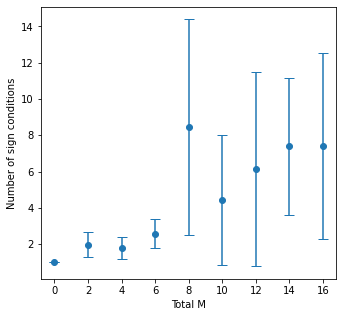

In [11]:
y_data = np.array([data_logger.network_data[m]['n_sign_conditions'] for m in range(len(data_logger.network_data))])
#y_data = np.array(y_data)
#y_data = np.array(n_unique_signs)
#M_values = np.array([data_logger.network_data[n]['conservation_changes']['M_0t1'] + data_logger.network_data[n]['conservation_changes']['M_1t0'] + data_logger.network_data[n]['conservation_changes']['M_0b1'] for n in range(len(data_logger.network_data))])
#M_values = np.array([data_logger.network_data[n]['interaction_matrix'].sum() for n in range(len(data_logger.network_data))])
#M_values = np.array([np.triu(data_logger.network_data[n]['interaction_matrix']).sum() for n in range(len(data_logger.network_data))])
M_values = np.array([np.triu(data_logger.network_data[n]['interaction_matrix']).sum() for n in range(len(data_logger.network_data))])

unique_M = np.unique(M_values)
n_sign_conditions_by_M = {M: y_data[M_values == M].tolist() for M in unique_M}
means = [np.mean(n_sign_conditions_by_M[M]) for M in unique_M]
stds = [np.std(n_sign_conditions_by_M[M]) for M in unique_M]
medians = [np.median(n_sign_conditions_by_M[M]) for M in unique_M]
mads = [np.median(np.abs(np.array(n_sign_conditions_by_M[M]) - np.median(n_sign_conditions_by_M[M]))) for M in unique_M]



plt.figure(figsize=(18,5))

plt.subplot(1,3,1)
plt.errorbar(unique_M, means, yerr=stds, fmt='o', capsize=5)
#plt.errorbar(unique_M, medians, yerr=mads, fmt='o', capsize=5)
plt.xlabel('Total M')
plt.ylabel('Number of sign conditions')
#plt.ylim(0,12)

# plt.subplot(1,3,2)
# plt.boxplot([y_data[M_values == M] for M in unique_M], positions=unique_M)
# plt.xlabel('Total M')
# plt.ylabel('Number of sign conditions')
# #plt.ylim(0,12)

# plt.subplot(1,3,3)
# samples_per_M = [np.sum(M_values == M) for M in unique_M]
# plt.bar(unique_M, samples_per_M)
# plt.yscale('log')
# plt.xlabel('Total M')
# plt.ylabel('Number of samples')

In [88]:
print(np.mean(n_sign_conditions_by_M[16]))

2.25


In [48]:
inds_by_M = {M: np.where(M_values == M)[0].tolist() for M in unique_M}
ys_by_M = {M: y_data[inds_by_M[M]] for M in unique_M}

M=12
l= [(ys_by_M[M][t], inds_by_M[M][t]) for t in range(len(ys_by_M[M]))]

sorted_list = sorted(l, key=lambda x: x[0], reverse=True)
print(sorted_list)
print("")


[(30, 826), (25, 706), (24, 11), (23, 209), (22, 897), (21, 321), (21, 839), (20, 2251), (19, 2068), (18, 403), (18, 2390), (18, 2459), (17, 2440), (16, 366), (16, 795), (16, 1192), (16, 2263), (15, 1202), (15, 1451), (15, 2323), (14, 197), (14, 1654), (13, 652), (13, 766), (12, 164), (12, 398), (12, 1089), (12, 1595), (12, 2062), (12, 2315), (11, 128), (11, 990), (11, 1040), (11, 1161), (11, 1308), (11, 1856), (11, 2116), (10, 60), (10, 269), (10, 484), (10, 491), (10, 529), (10, 579), (10, 731), (10, 1582), (10, 2152), (10, 2218), (9, 206), (9, 244), (9, 261), (9, 283), (9, 477), (9, 1029), (9, 1108), (9, 2112), (8, 340), (8, 1077), (8, 1893), (8, 1978), (8, 1988), (7, 264), (7, 369), (7, 868), (7, 2389), (6, 0), (6, 136), (6, 1329), (6, 1537), (5, 1346), (5, 1602), (5, 1608), (5, 2205), (4, 20), (4, 326), (4, 389), (4, 500), (4, 541), (4, 862), (4, 1227), (4, 1358), (4, 1396), (4, 1532), (4, 1665), (4, 1711), (4, 1768), (4, 1790), (4, 1972), (4, 1991), (4, 2013), (4, 2028), (4, 2050

In [173]:
data_logger.network_data[network_index].keys()

dict_keys(['network_params', 'interaction_matrix', 'cycles', 'n_cycles', 'sign_conditions', 'n_sign_conditions', 'C_full_list', 'l0_list', 'iteration', 'seed', 'dC_dl_list', 'E_range', 'B_range', 'F_range', 'C0', 'beta', 'sample_count', 'convergence_reached'])

12.0
30
5


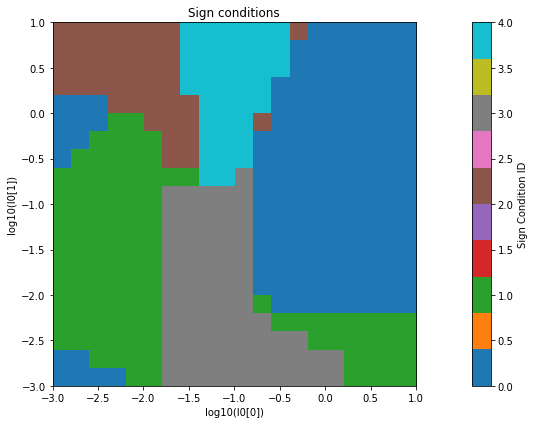

In [50]:
network_index = 826

print(M_values[network_index])
print(data_logger.network_data[network_index]['n_sign_conditions'])


C_ind = 6
l_ind = 1
l0_list = data_logger.network_data[network_index]['l0_list']
C_full_list = data_logger.network_data[network_index]['C_full_list']

l0_x = np.array([l0[0] for l0 in l0_list])  
l0_y = np.array([l0[1] for l0 in l0_list])  
d_log_C_d_log_l0_list = convert_to_log(data_logger, network_index)
dC_dl_data = data_logger.network_data[network_index]['dC_dl_list']

#C_data = [C_full_list[i][C_ind]  for i in range(len(C_full_list))]
#C_data = [np.log10(C_full_list[i][C_ind])  for i in range(len(C_full_list))]
C_data = [C_full_list[i][C_ind]  for i in range(len(C_full_list))]
#C_data = [dC_dl_data[i][C_ind][l_ind]  for i in range(len(dC_dl_data))]
C_data = [d_log_C_d_log_l0_list[i][C_ind][l_ind]  for i in range(len(C_full_list))]


cut = 1e-8

#sign_condition_ids = get_sign_condition_ids([clamp_sign(p, cut).tolist() for p in d_log_C_d_log_l0_list])
#n_conds, sign_condition_ids = count_unique_tensors_with_ids([clamp_sign(p, cut).tolist() for p in d_log_C_d_log_l0_list], conservative_comparison = True)#, log_scale = False)

n_conds, sign_condition_ids = get_n_unique_signs_index(network_index, data_logger, 1e-6, conservative_comparison = True, log_scale = False, dims = sc_grad_dims)
print(n_conds)

# Create figure with two subplots side by side
fig, (ax) = plt.subplots(1, 1, figsize=(16,6))

p_vals = C_data
#p_vals = [clamp_sign(p, cut) for p in p_vals]
cmap = 'viridis'

p_vals = sign_condition_ids
cmap = 'tab10'

# Reshape sign_condition_ids into a 2D array
n = int(np.sqrt(len(p_vals)))  # Assuming square grid
p_values = np.array(p_vals).reshape(n, n).T

# Plot using imshow
im = ax.imshow(p_values, origin='lower', aspect='auto',
                extent=[np.log10(l0_x.min()), np.log10(l0_x.max()),
                        np.log10(l0_y.min()), np.log10(l0_y.max())],
                cmap=cmap)

ax.set_xlabel('log10(l0[0])')
ax.set_ylabel('log10(l0[1])')
ax.set_title('Sign conditions')
ax.set_aspect(1)

fig.colorbar(im, ax=ax, label='Sign Condition ID')

plt.tight_layout()
plt.show()

In [13]:
dC_dl_data[20]

array([[  -0.49997529,    0.        ,    0.        ],
       [   0.55395593,   -0.        ,   -0.        ],
       [   0.44599464,   -0.        ,   -0.        ],
       [   0.        ,   -0.49994516,    0.        ],
       [  -0.        ,    0.80652617,   -0.        ],
       [  -0.        ,    0.19336414,   -0.        ],
       [ -32.98130776,    0.        ,   -0.82026114],
       [ 100.30359157,   -0.        ,    0.19353493],
       [-137.83158946,   -0.        ,    0.23573331],
       [  70.50930565,   -0.        ,    0.3909929 ]])

In [12]:
data_logger.network_data[network_index]['interaction_matrix']

array([[0., 0., 6.],
       [0., 0., 0.],
       [0., 0., 0.]])

In [32]:
inds_by_M = {M: np.where(M_values == M)[0].tolist() for M in unique_M}
ys_by_M = {M: y_data[inds_by_M[M]] for M in unique_M}

M=12
l= [(ys_by_M[M][t], inds_by_M[M][t]) for t in range(len(ys_by_M[M]))]

sorted_list = sorted(l, key=lambda x: x[0], reverse=True)
print(sorted_list)
print("")

[(8, 489), (6, 271), (6, 456), (5, 268), (4, 71), (4, 151), (4, 468), (4, 475), (3, 43), (3, 211), (3, 355), (3, 484), (2, 8), (2, 10), (2, 26), (2, 30), (2, 34), (2, 36), (2, 115), (2, 249), (2, 279), (2, 311), (2, 349), (2, 352), (2, 353), (2, 359), (2, 400), (2, 412), (2, 430), (2, 439), (2, 445), (2, 449), (2, 498), (1, 44), (1, 63), (1, 68), (1, 81), (1, 97), (1, 137), (1, 139), (1, 150), (1, 154), (1, 187), (1, 196), (1, 200), (1, 204), (1, 228), (1, 232), (1, 235), (1, 240), (1, 253), (1, 255), (1, 274), (1, 332), (1, 341), (1, 370), (1, 407), (1, 413), (1, 420), (1, 452), (1, 483)]



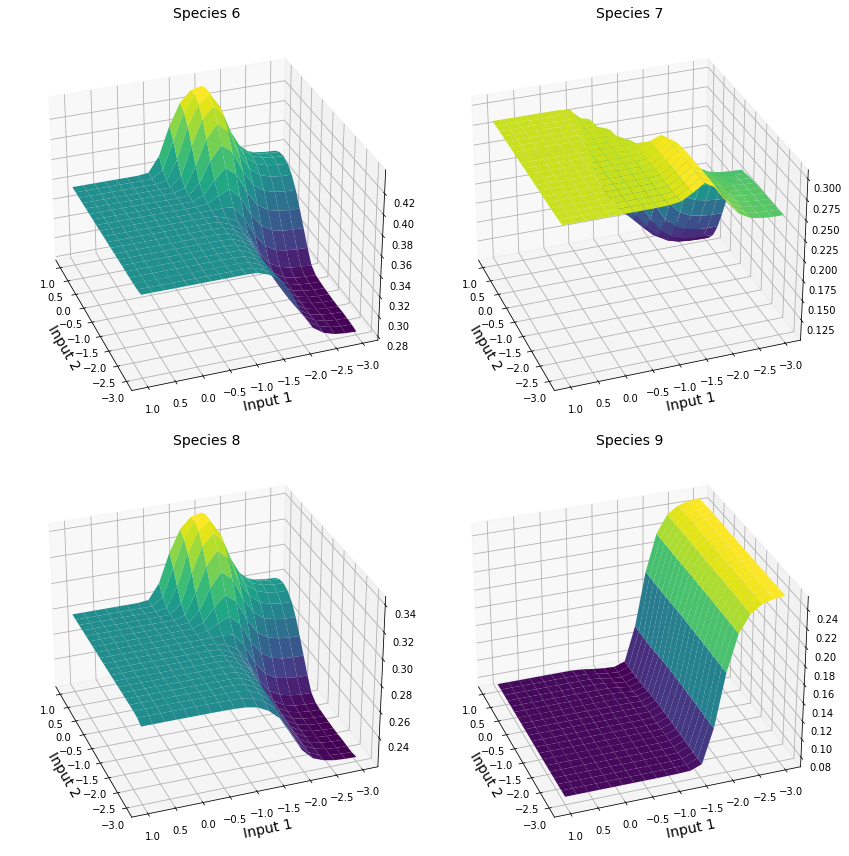

In [51]:
from scipy.interpolate import griddata
from matplotlib import cm

network_index = 826

l0_list = data_logger.network_data[network_index]['l0_list']
C_full_list = data_logger.network_data[network_index]['C_full_list']

l0_x = np.array([l0[0] for l0 in l0_list])
l0_y = np.array([l0[1] for l0 in l0_list])

# Get number of species from first C_full entry
n_species = C_full_list[0].shape[0]

# Calculate number of rows/cols needed for subplots
n_rows = int(np.ceil(np.sqrt(n_species)))
n_cols = int(np.ceil(n_species / n_rows))

# Create 3D figure with subplots
fig = plt.figure(figsize=(12,12))

for i, C_ind in enumerate([6,7,8,9]):
    # Get log concentrations for this species
    # C_data = [np.log10(C_full_list[i][C_ind]) for j in range(len(C_full_list))]
    C_data = [C_full_list[j][C_ind] for j in range(len(C_full_list))]
    
    # Create 3D subplot in 2x2 grid
    ax = fig.add_subplot(2, 2, i+1, projection='3d')
    
    
    # Create meshgrid for 3D surface
    X, Y = np.meshgrid(np.unique(l0_x), np.unique(l0_y))
    Z = np.array(C_data).reshape(X.shape)
    

    # Take the log of the coordinates
    log_X = np.log10(X)
    log_Y = np.log10(Y)

    # Create finer interpolation grid in log space
    # Determine the range of your log-transformed data
    log_x_min, log_x_max = log_X.min(), log_X.max()
    log_y_min, log_y_max = log_Y.min(), log_Y.max()

    # Create finer grid (adjust the number of points as needed)
    n_points_x = 20  # Increase this for finer interpolation
    n_points_y = 20

    # Generate uniform linear-spaced points in log space
    log_x_fine = np.linspace(log_x_min, log_x_max, n_points_x)
    log_y_fine = np.linspace(log_y_min, log_y_max, n_points_y)

    # Create the fine meshgrid
    log_X_fine, log_Y_fine = np.meshgrid(log_x_fine, log_y_fine)

    # Prepare data for interpolation
    # Flatten the log-transformed data points
    points = np.column_stack((log_X.ravel(), log_Y.ravel()))
    values = Z.ravel()

    # Do linear interpolation on the log-transformed data
    Z_fine = griddata(points, values, (log_X_fine, log_Y_fine), method='linear')
    #my_col = cm.jet(Z_fine/np.amax(Z_fine))

    # Plot the interpolated surface
    surf = ax.plot_surface(log_X_fine, log_Y_fine, Z_fine,  cmap='viridis')

    # Set viewpoint 
    ax.view_init(elev=30, azim=160)
    
    fs = 14
    ax.set_facecolor('white')
    ax.set_xlabel('Input 2', fontsize=fs)
    ax.set_ylabel('Input 1', fontsize=fs)
    #ax.set_zlabel('C', fontsize=fs)
    # ax.set_xscale('log')
    # ax.set_yscale('log')
    #ax.set_zlim(0, 1)
    ax.set_title(f'Species {C_ind}', fontsize=fs)
    
    # Add colorbar
    #fig.colorbar(surf, ax=ax, shrink=0.5)

plt.tight_layout()
plt.show()

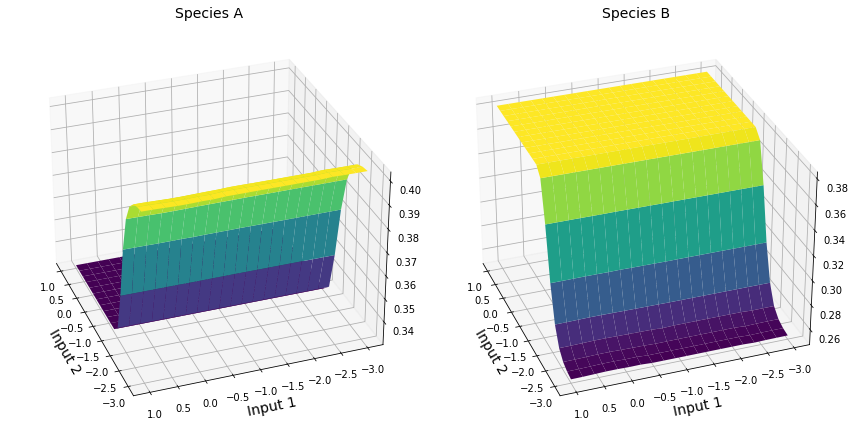

In [29]:
from scipy.interpolate import griddata
from matplotlib import cm

network_index = 13

l0_list = data_logger.network_data[network_index]['l0_list']
C_full_list = data_logger.network_data[network_index]['C_full_list']

l0_x = np.array([l0[0] for l0 in l0_list])
l0_y = np.array([l0[1] for l0 in l0_list])

# Get number of species from first C_full entry
n_species = C_full_list[0].shape[0]

# Calculate number of rows/cols needed for subplots
n_rows = int(np.ceil(np.sqrt(n_species)))
n_cols = int(np.ceil(n_species / n_rows))

# Create 3D figure with subplots
fig = plt.figure(figsize=(12,6))

names = ["A","B"]
for i, C_ind in enumerate([6,7]):
    # Get log concentrations for this species
    # C_data = [np.log10(C_full_list[i][C_ind]) for j in range(len(C_full_list))]
    C_data = [C_full_list[j][C_ind] for j in range(len(C_full_list))]
    
    # Create 3D subplot in 2x2 grid
    ax = fig.add_subplot(1, 2, i+1, projection='3d')
    
    
    # Create meshgrid for 3D surface
    X, Y = np.meshgrid(np.unique(l0_x), np.unique(l0_y))
    Z = np.array(C_data).reshape(X.shape)
    

    # Take the log of the coordinates
    log_X = np.log10(X)
    log_Y = np.log10(Y)

    # Create finer interpolation grid in log space
    # Determine the range of your log-transformed data
    log_x_min, log_x_max = log_X.min(), log_X.max()
    log_y_min, log_y_max = log_Y.min(), log_Y.max()

    # Create finer grid (adjust the number of points as needed)
    n_points_x = 20  # Increase this for finer interpolation
    n_points_y = 20

    # Generate uniform linear-spaced points in log space
    log_x_fine = np.linspace(log_x_min, log_x_max, n_points_x)
    log_y_fine = np.linspace(log_y_min, log_y_max, n_points_y)

    # Create the fine meshgrid
    log_X_fine, log_Y_fine = np.meshgrid(log_x_fine, log_y_fine)

    # Prepare data for interpolation
    # Flatten the log-transformed data points
    points = np.column_stack((log_X.ravel(), log_Y.ravel()))
    values = Z.ravel()

    # Do linear interpolation on the log-transformed data
    Z_fine = griddata(points, values, (log_X_fine, log_Y_fine), method='linear')
    #my_col = cm.jet(Z_fine/np.amax(Z_fine))

    # Plot the interpolated surface
    surf = ax.plot_surface(log_X_fine, log_Y_fine, Z_fine,  cmap='viridis')

    # Set viewpoint 
    ax.view_init(elev=30, azim=160)
    
    fs = 14
    ax.set_facecolor('white')
    ax.set_xlabel('Input 2', fontsize=fs)
    ax.set_ylabel('Input 1', fontsize=fs)
    #ax.set_zlabel('C', fontsize=fs)
    # ax.set_xscale('log')
    # ax.set_yscale('log')
    #ax.set_zlim(0, 1)
    ax.set_title(f'Species {names[i]}', fontsize=fs)
    
    # Add colorbar
    #fig.colorbar(surf, ax=ax, shrink=0.5)

plt.tight_layout()
plt.show()

In [45]:
[C_full_list[j][6] for j in range(len(C_full_list))]

[0.5502897146170401,
 0.5502897146170402,
 0.5502897146170401,
 0.5502897146170402,
 0.5502897146170417,
 0.55028971461706,
 0.5502897146170407,
 0.5502897146170402,
 0.5502897146170401,
 0.550289714617041,
 0.55028971461704,
 0.5502897146170398,
 0.5502897146170402,
 0.5502897146170401,
 0.5502897146170402,
 0.5502897146170406,
 0.5502897146170406,
 0.5502897146170402,
 0.5502897146170399,
 0.5502897146170402,
 0.5502897146158052,
 0.5502897146170402,
 0.5502897146170403,
 0.5502897146170401,
 0.5502897146170397,
 0.5502897146170401,
 0.5502897146170405,
 0.5502897146170405,
 0.5502897146170709,
 0.55028971461704,
 0.55028971461704,
 0.5502897146170402,
 0.5502897146170402,
 0.55028971461704,
 0.55028971461704,
 0.5502897146170448,
 0.5502897146170406,
 0.5502897146170401,
 0.5502897146170421,
 0.5502897146170378,
 0.5502897146170398,
 0.55028971461704,
 0.55028971461704,
 0.5502897146170403,
 0.5502897146170399,
 0.55028971461704,
 0.5502897146170401,
 0.5502897146170397,
 0.55028971

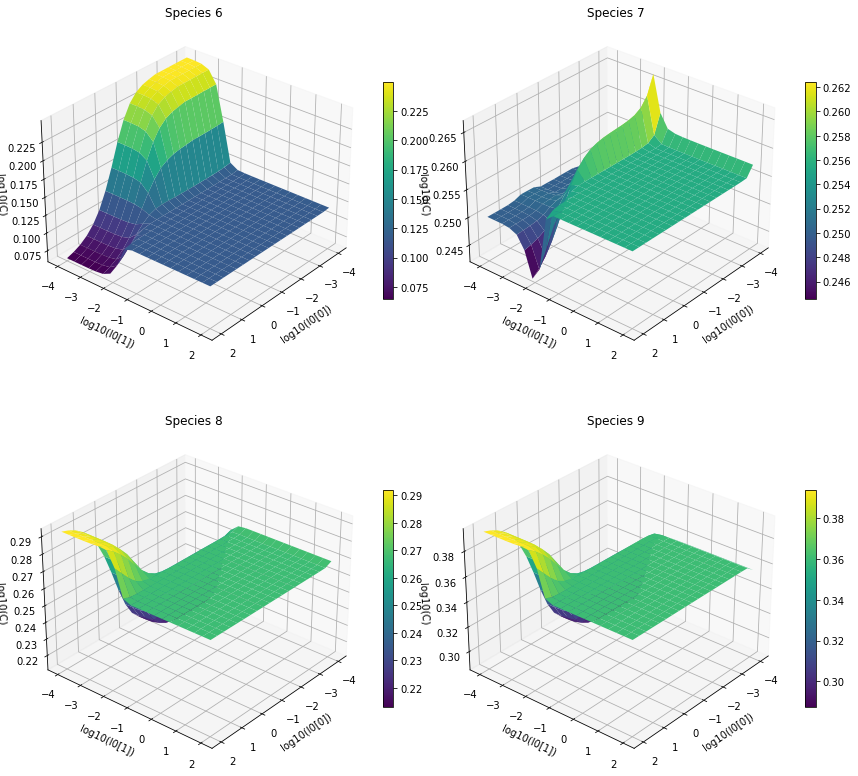

In [39]:
network_index = 1987

l0_list = data_logger.network_data[network_index]['l0_list']
C_full_list = data_logger.network_data[network_index]['C_full_list']

l0_x = np.array([l0[0] for l0 in l0_list])
l0_y = np.array([l0[1] for l0 in l0_list])

# Get number of species from first C_full entry
n_species = C_full_list[0].shape[0]

# Calculate number of rows/cols needed for subplots
n_rows = int(np.ceil(np.sqrt(n_species)))
n_cols = int(np.ceil(n_species / n_rows))

# Create 3D figure with subplots
fig = plt.figure(figsize=(12,12))

for i, C_ind in enumerate([6,7,8,9]):
    # Get log concentrations for this species
    C_data = [np.log10(C_full_list[i][C_ind]) for i in range(len(C_full_list))]
    C_data = [C_full_list[i][C_ind] for i in range(len(C_full_list))]
    
    # Create 3D subplot in 2x2 grid
    ax = fig.add_subplot(2, 2, i+1, projection='3d')
    
    # Create meshgrid for 3D surface
    X, Y = np.meshgrid(np.unique(l0_x), np.unique(l0_y))
    Z = np.array(C_data).reshape(X.shape)
    
    # Plot surface
    surf = ax.plot_surface(np.log10(X), np.log10(Y), Z, cmap='viridis')
    
    # Set viewpoint 
    ax.view_init(elev=30, azim=40)
    
    ax.set_xlabel('log10(l0[0])')
    ax.set_ylabel('log10(l0[1])')
    ax.set_zlabel('log10(C)')
    ax.set_title(f'Species {C_ind}')
    
    # Add colorbar
    fig.colorbar(surf, ax=ax, shrink=0.5)

plt.tight_layout()
plt.show()

In [161]:
5 * 13849.73 / 3600

19.23573611111111

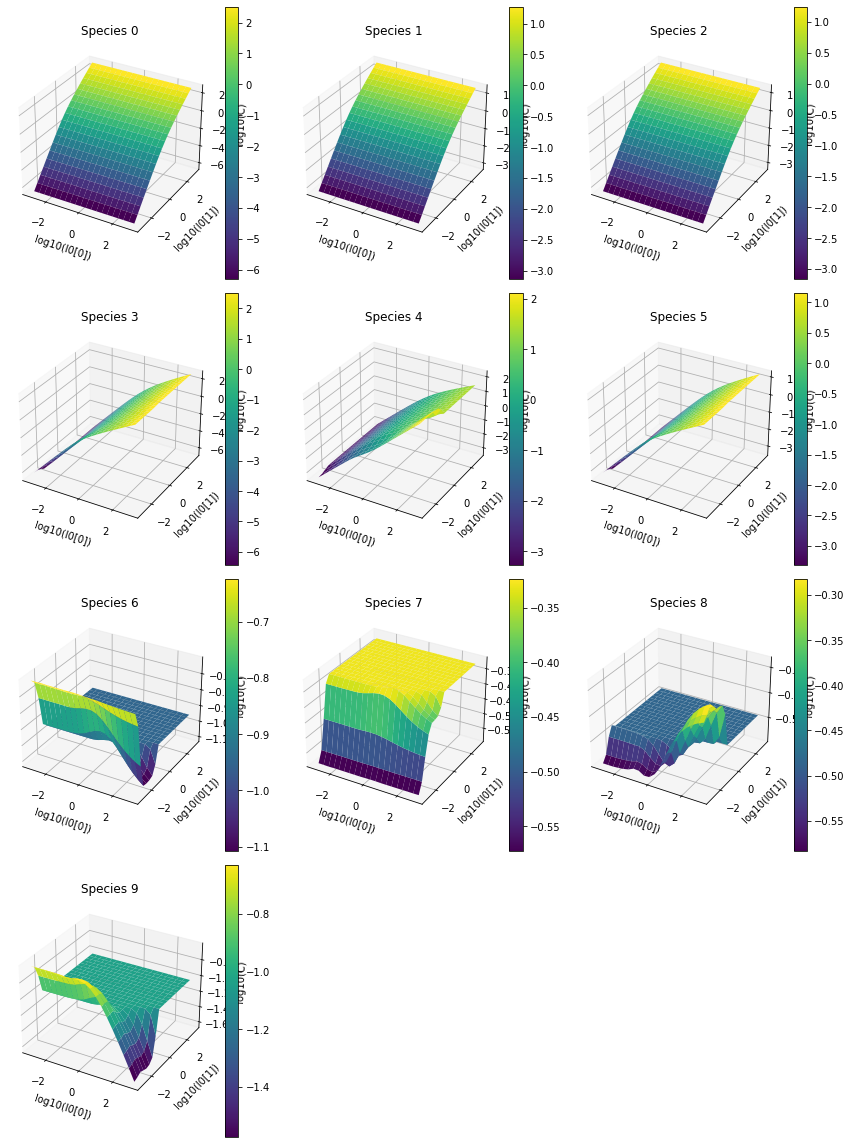

In [113]:
network_index = 287

l0_list = data_logger.network_data[network_index]['l0_list']
C_full_list = data_logger.network_data[network_index]['C_full_list']

l0_x = np.array([l0[0] for l0 in l0_list])
l0_y = np.array([l0[1] for l0 in l0_list])

# Get number of species from first C_full entry
n_species = C_full_list[0].shape[0]

# Calculate number of rows/cols needed for subplots
n_rows = int(np.ceil(np.sqrt(n_species)))
n_cols = int(np.ceil(n_species / n_rows))

# Create 3D figure with subplots
fig = plt.figure(figsize=(4*n_cols, 4*n_rows))

for C_ind in range(n_species):
    # Get log concentrations for this species
    C_data = [np.log10(C_full_list[i][C_ind]) for i in range(len(C_full_list))]
    
    # Create 3D subplot
    ax = fig.add_subplot(n_rows, n_cols, C_ind+1, projection='3d')
    
    # Create meshgrid for 3D surface
    X, Y = np.meshgrid(np.unique(l0_x), np.unique(l0_y))
    Z = np.array(C_data).reshape(X.shape)
    
    # Plot surface
    surf = ax.plot_surface(np.log10(X), np.log10(Y), Z, cmap='viridis')
    
    ax.set_xlabel('log10(l0[0])')
    ax.set_ylabel('log10(l0[1])')
    ax.set_zlabel('log10(C)')
    ax.set_title(f'Species {C_ind}')
    
    # Add colorbar
    fig.colorbar(surf, ax=ax)

plt.tight_layout()
plt.show()

In [ ]:
data_logger.get_network_by_index(10).keys()


dict_keys(['network_params', 'conservation_changes', 'cycles', 'n_cycles', 'sign_conditions', 'n_sign_conditions', 'C_full_list', 'l0_list', 'iteration', 'seed', 'dC_dl_list', 'E_range', 'B_range', 'F_range', 'C0', 'beta', 'sample_count', 'convergence_reached'])

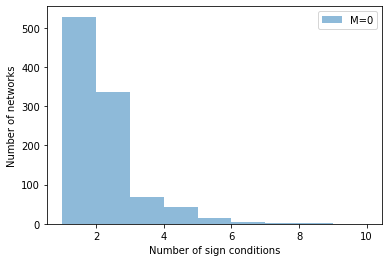

In [ ]:
plt.hist(n_unique_signs, bins=range(1, 11), alpha=0.5)
plt.xlabel('Number of sign conditions')
plt.ylabel('Number of networks')
plt.legend(['M=0', 'M=2', 'M=4', 'M=6', 'M=8', 'M=10'])
plt.yscale('log')
plt.show()

In [50]:
print(type(np.array(n_unique_signs)))

<class 'numpy.ndarray'>


Data loaded from /Users/csfloyd/Dropbox/Projects/GlycanAnalysis/Dirs/F_range/5/SavedData.pkl
2.269230769230769


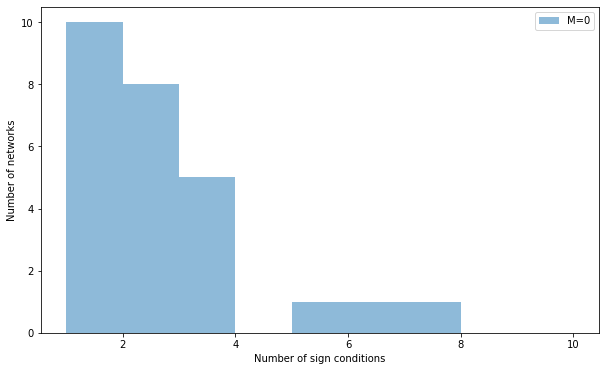

In [ ]:
path = "/Users/csfloyd/Dropbox/Projects/GlycanAnalysis/Dirs/F_range"
file = path + "/" + str(4) + "/SavedData.pkl"
data_logger = NetworkDataLogger(file)

M_values = np.array([data_logger.network_data[n]['conservation_changes']['M_0t1'] + data_logger.network_data[n]['conservation_changes']['M_1t0'] + data_logger.network_data[n]['conservation_changes']['M_0b1'] for n in range(len(data_logger.network_data))])
n_sign_conditions = np.array([data_logger.network_data[n]['n_sign_conditions'] for n in range(len(data_logger.network_data))])
y_data = np.array(n_unique_signs)

# Group n_sign_conditions by M values
unique_M = np.unique(M_values)

n_sign_conditions_by_M = {M: y_data[M_values == M].tolist() for M in unique_M}


M = 8
print(np.mean(n_sign_conditions_by_M[M]))
plt.figure(figsize=(10,6))
plt.hist(n_sign_conditions_by_M[M], bins=range(1, 11), alpha=0.5)
plt.xlabel('Number of sign conditions')
plt.ylabel('Number of networks')
plt.legend(['M=0', 'M=2', 'M=4', 'M=6', 'M=8', 'M=10'])
#plt.xlim(0,60)
plt.show()

Data loaded from /Users/csfloyd/Dropbox/Projects/GlycanAnalysis/Dirs/F_range/5/SavedData.pkl
1.3893376413570275


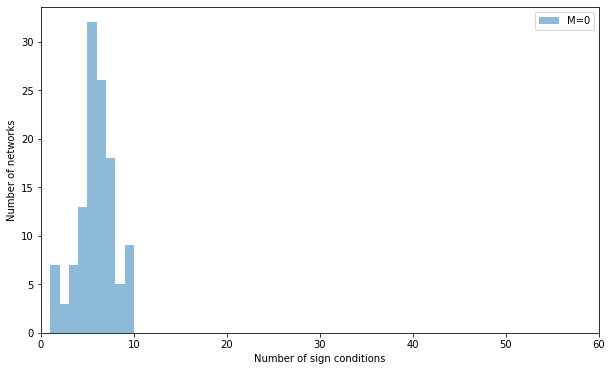

In [41]:

path = "/Users/csfloyd/Dropbox/Projects/GlycanAnalysis/Dirs/F_range"
file = path + "/" + str(5) + "/SavedData.pkl"
data_logger = NetworkDataLogger(file)

M_values = np.array([data_logger.network_data[n]['conservation_changes']['M_0t1'] + data_logger.network_data[n]['conservation_changes']['M_1t0'] + data_logger.network_data[n]['conservation_changes']['M_0b1'] for n in range(len(data_logger.network_data))])
n_sign_conditions = np.array([data_logger.network_data[n]['n_sign_conditions'] for n in range(len(data_logger.network_data))])

# Group n_sign_conditions by M values
unique_M = np.unique(M_values)
n_sign_conditions_by_M = {M: n_sign_conditions[M_values == M].tolist() for M in unique_M}
n_sign_conditions_by_M[0]

print(np.mean(n_sign_conditions_by_M[0]))
plt.figure(figsize=(10,6))
plt.hist(n_sign_conditions_by_M[6], bins=range(1, 11), alpha=0.5)
# plt.hist(n_sign_conditions_by_M[2], bins=range(1, 150, 10), alpha=0.5)
# plt.hist(n_sign_conditions_by_M[4], bins=range(1, 150, 10), alpha=0.5)
# plt.hist(n_sign_conditions_by_M[6], bins=range(1, 150, 10), alpha=0.5)
# plt.hist(n_sign_conditions_by_M[8], bins=range(1, 150, 10), alpha=0.5)
# plt.hist(n_sign_conditions_by_M[10], bins=range(1, 150, 10), alpha=0.5)
plt.xlabel('Number of sign conditions')
plt.ylabel('Number of networks')
plt.legend(['M=0', 'M=2', 'M=4', 'M=6', 'M=8', 'M=10'])
plt.xlim(0,60)
plt.show()


In [22]:
6916.38 / 3600

1.9212166666666668

In [3]:
path = "/Users/csfloyd/Dropbox/Projects/GlycanAnalysis/Dirs/F_range_3"

vars = [0, 1, 2, 4]
M_list = []


file = path + "/" + str(0) + "/SavedData.pkl"
data_logger = NetworkDataLogger(file)
M_values = np.array([data_logger.network_data[n]['conservation_changes']['M_0t1'] + data_logger.network_data[n]['conservation_changes']['M_1t0'] + data_logger.network_data[n]['conservation_changes']['M_0b1'] for n in range(len(data_logger.network_data))])
n_sign_conditions = np.array([data_logger.network_data[n]['n_sign_conditions'] for n in range(len(data_logger.network_data))])

plt.figure(figsize=(10,6))
sns.violinplot(x=M_values, y=n_sign_conditions, inner = "point")
plt.xlabel('Total M')


FileNotFoundError: [Errno 2] No such file or directory: '/Users/csfloyd/Dropbox/Projects/GlycanAnalysis/Dirs/F_range_3/0/SavedData.pkl'

Data loaded from /Users/csfloyd/Dropbox/Projects/GlycanAnalysis/Dirs/F_range_3/4/SavedData.pkl


Text(0.5, 0, 'Total M')

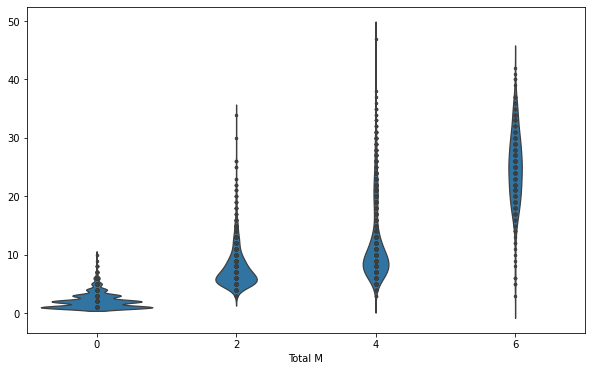

In [31]:
path = "/Users/csfloyd/Dropbox/Projects/GlycanAnalysis/Dirs/F_range_3"

vars = [0, 1, 2, 4, 5]
M_list = []


file = path + "/" + str(4) + "/SavedData.pkl"
data_logger = NetworkDataLogger(file)
M_values = np.array([data_logger.network_data[n]['conservation_changes']['M_0t1'] + data_logger.network_data[n]['conservation_changes']['M_1t0'] + data_logger.network_data[n]['conservation_changes']['M_0b1'] for n in range(len(data_logger.network_data))])
n_sign_conditions = np.array([data_logger.network_data[n]['n_sign_conditions'] for n in range(len(data_logger.network_data))])

plt.figure(figsize=(10,6))
sns.violinplot(x=M_values, y=n_sign_conditions, inner = "point")
plt.xlabel('Total M')

Data loaded from /Users/csfloyd/Dropbox/Projects/GlycanAnalysis/Dirs/F_range_2/5/SavedData.pkl
Data loaded from /Users/csfloyd/Dropbox/Projects/GlycanAnalysis/Dirs/F_range_2/0/SavedData.pkl
23.694444444444443
22.390243902439025


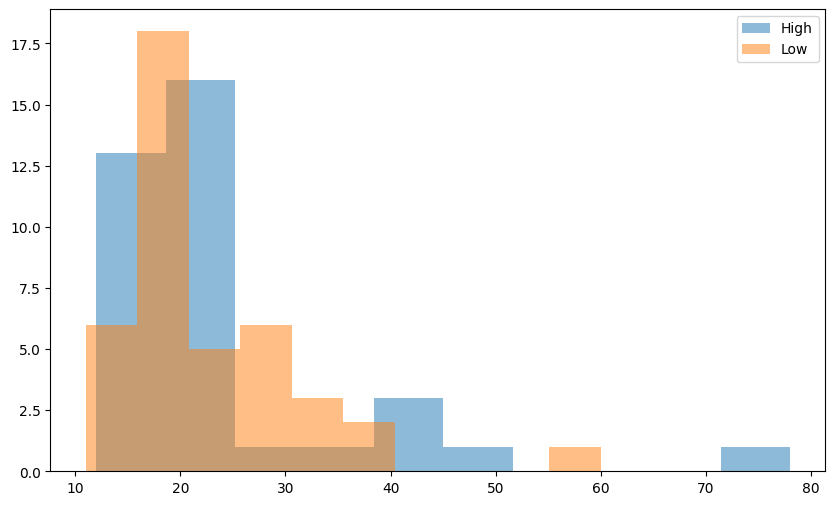

In [37]:
path = "/Users/csfloyd/Dropbox/Projects/GlycanAnalysis/Dirs/F_range_2"
file = path + "/" + str(5) + "/SavedData.pkl"
data_logger_high = NetworkDataLogger(file)

M_values_high = np.array([data_logger_high.network_data[n]['conservation_changes']['M_0t1'] + data_logger_high.network_data[n]['conservation_changes']['M_1t0'] + data_logger_high.network_data[n]['conservation_changes']['M_0b1'] for n in range(len(data_logger_high.network_data))])
n_sign_conditions_high = np.array([data_logger_high.network_data[n]['n_sign_conditions'] for n in range(len(data_logger_high.network_data))])

# Group n_sign_conditions by M values
unique_M = np.unique(M_values_high)
n_sign_conditions_by_M_high = {M: n_sign_conditions_high[M_values_high == M].tolist() for M in unique_M}
n_sign_conditions_by_M_high[0]

file = path + "/" + str(0) + "/SavedData.pkl"
data_logger_low = NetworkDataLogger(file)

M_values_low = np.array([data_logger_low.network_data[n]['conservation_changes']['M_0t1'] + data_logger_low.network_data[n]['conservation_changes']['M_1t0'] + data_logger_low.network_data[n]['conservation_changes']['M_0b1'] for n in range(len(data_logger_low.network_data))])
n_sign_conditions_low = np.array([data_logger_low.network_data[n]['n_sign_conditions'] for n in range(len(data_logger_low.network_data))])

# Group n_sign_conditions by M values
M_ind = 4
unique_M = np.unique(M_values_low)
n_sign_conditions_by_M_low = {M: n_sign_conditions_low[M_values_low == M].tolist() for M in unique_M}


print(np.mean(n_sign_conditions_by_M_high[M_ind]))
print(np.mean(n_sign_conditions_by_M_low[M_ind]))
plt.figure(figsize=(10,6))
plt.hist(n_sign_conditions_by_M_high[M_ind], alpha=0.5)
plt.hist(n_sign_conditions_by_M_low[M_ind], alpha=0.5)
plt.legend(['High', 'Low'])
#plt.xlim(0,60)
plt.show()

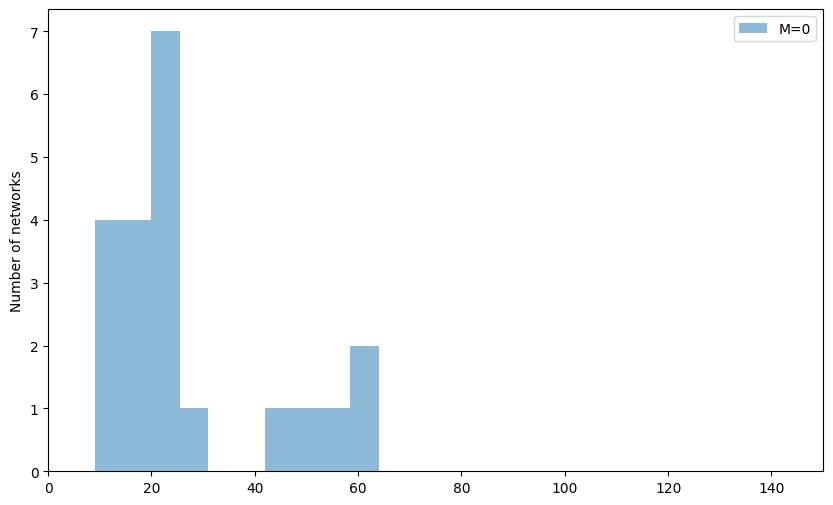

In [24]:
plt.figure(figsize=(10,6))
#plt.hist(n_sign_conditions_by_M[0], bins=range(1, 11), alpha=0.5)
plt.hist(n_sign_conditions_by_M[6], alpha=0.5)
plt.ylabel('Number of networks')
plt.legend(['M=0', 'M=2', 'M=4', 'M=6', 'M=8', 'M=10'])
plt.xlim(0,150)
plt.show()

[10, 22, 6, 49, 2, 23, 19, 3, 4, 96, 95, 5, 67, 1, 13, 3, 2, 4, 2, 23, 68, 5, 2, 23, 17, 3, 90, 2, 8, 3, 4, 3, 2, 44, 19, 21, 3, 46, 3, 14, 3, 2, 5, 15, 15, 15, 2, 2, 17, 16, 3, 6, 21, 3, 3, 2, 1, 7, 5, 17, 5, 15, 2, 22, 1, 20, 1, 4, 14, 14, 1, 39, 9, 13, 4, 1, 1, 3, 12, 2, 2, 20, 17, 5, 4, 3, 2, 4, 6, 2, 4, 14, 3, 21, 4, 15, 24, 1, 12, 9, 1, 28, 30, 78, 10, 3, 41, 26, 18, 24, 7, 4, 39, 4, 5, 44, 3, 4, 24, 2, 28, 1, 16, 22, 20, 19, 3, 49, 15, 24, 6, 22, 15, 1, 4, 3, 3, 15, 11, 53, 108, 16, 64, 2, 11, 1, 14, 2, 3, 1, 8, 1, 4, 2, 3, 46, 2, 16, 11, 22, 1, 2, 2, 1, 3, 2, 1, 18, 17, 2, 1, 7, 15, 4, 56, 1, 4, 1, 13, 1, 2, 4, 4, 12, 11, 3, 5, 15, 3, 1, 59, 4, 49, 43, 2, 2, 19, 5, 6, 3, 10, 6, 1, 24, 5, 5, 1, 2, 13, 3, 3, 4, 14, 2, 2, 20, 6, 2, 27, 1, 4, 2, 1, 15, 3, 40, 20, 3, 24, 2, 8, 15, 2, 40, 2, 3, 4, 4, 2, 3, 19, 5, 1, 2, 12, 3, 17, 2, 2, 49, 1, 2, 2, 3, 13, 1, 3, 3, 25, 11, 3, 2, 5, 3, 2, 4, 7, 2, 2, 10, 2, 2, 2, 2, 1, 3, 2, 2, 3, 53, 18, 22, 6, 29, 12, 54, 14, 6, 7, 1, 1, 3, 2, 4, 2, 

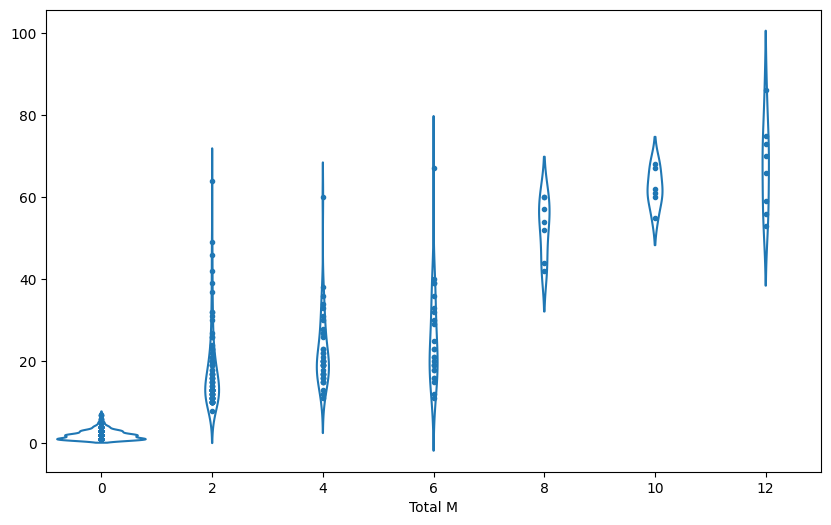

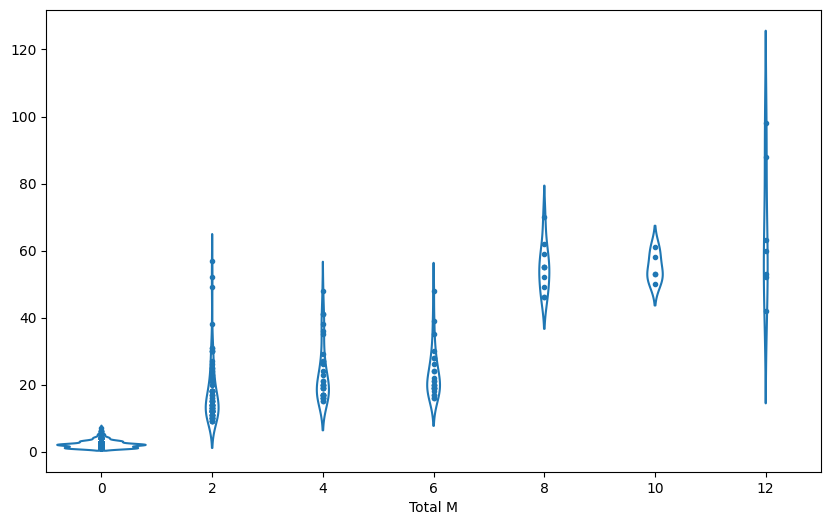

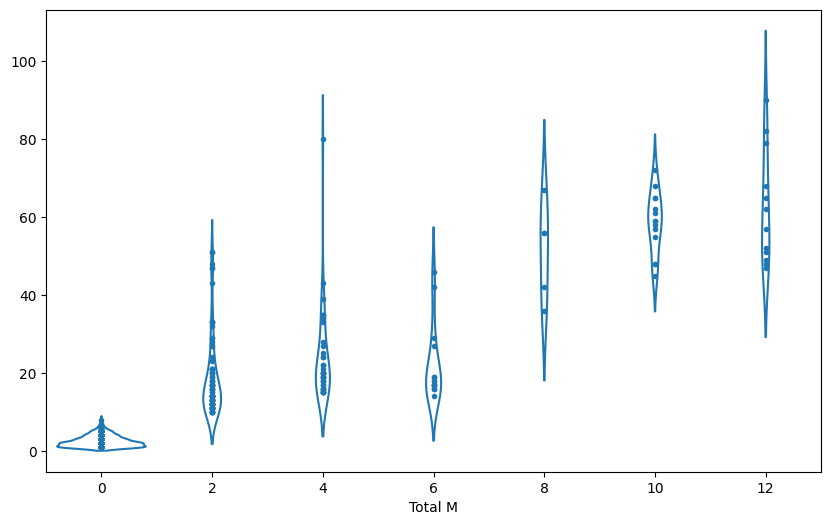

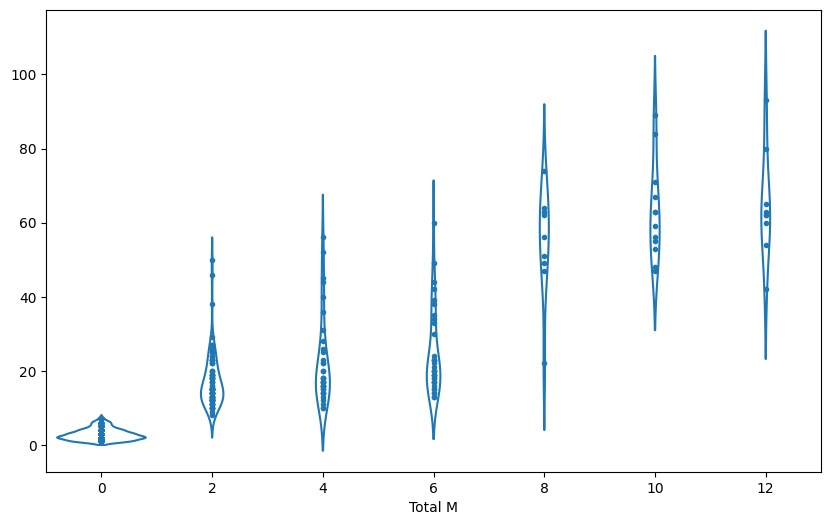

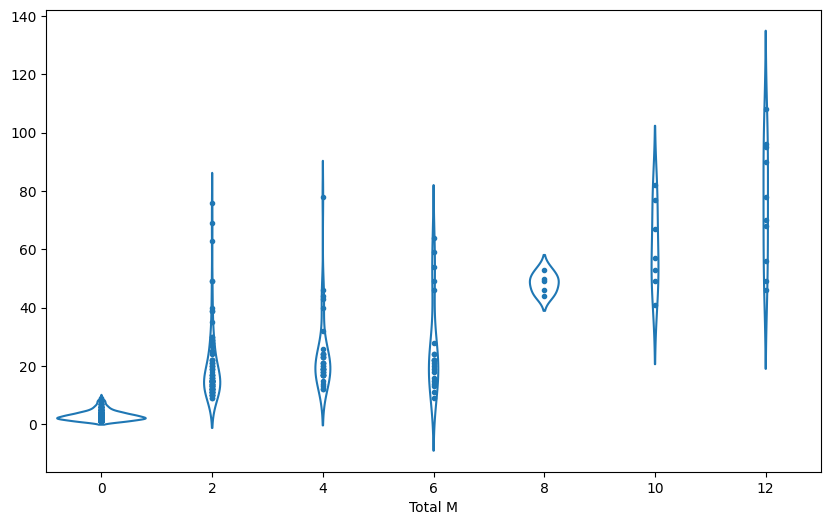

In [26]:
print([data_logger.network_data[n]['n_sign_conditions'] for n in range(len(data_logger.network_data))])
print(len(data_logger.network_data))



path = "/Users/csfloyd/Dropbox/Projects/GlycanAnalysis/Dirs/F_range_2"

vars = [0, 1, 2, 4, 5]
M_list = []

for var in vars:
    file = path + "/" + str(var) + "/SavedData.pkl"
    data_logger = NetworkDataLogger(file)
    M_values = np.array([data_logger.network_data[n]['conservation_changes']['M_0t1'] + data_logger.network_data[n]['conservation_changes']['M_1t0'] + data_logger.network_data[n]['conservation_changes']['M_0b1'] for n in range(len(data_logger.network_data))])
    n_sign_conditions = np.array([data_logger.network_data[n]['n_sign_conditions'] for n in range(len(data_logger.network_data))])

    plt.figure(figsize=(10,6))
    sns.violinplot(x=M_values, y=n_sign_conditions, inner = "point", fill = False)
    plt.xlabel('Total M')






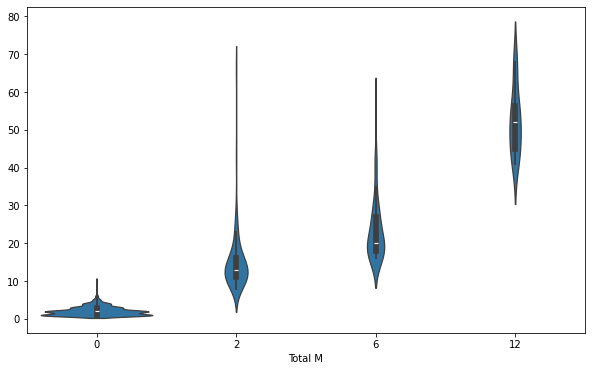

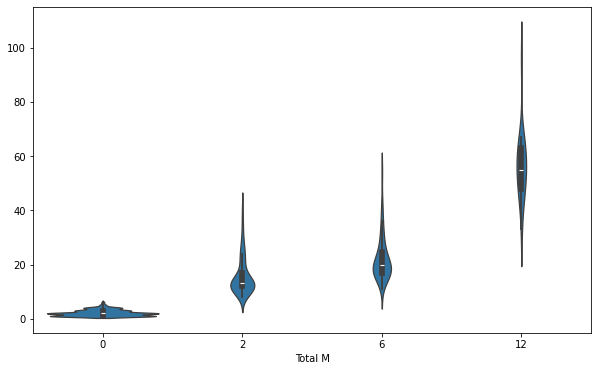

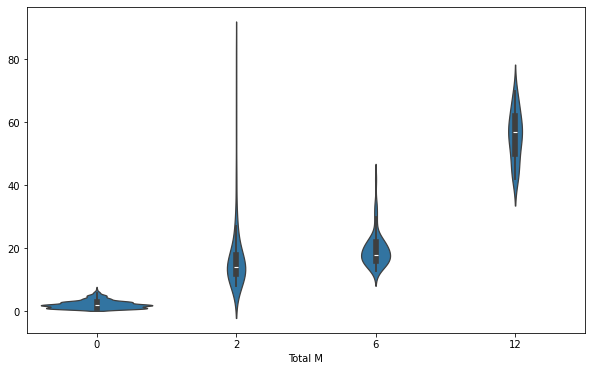

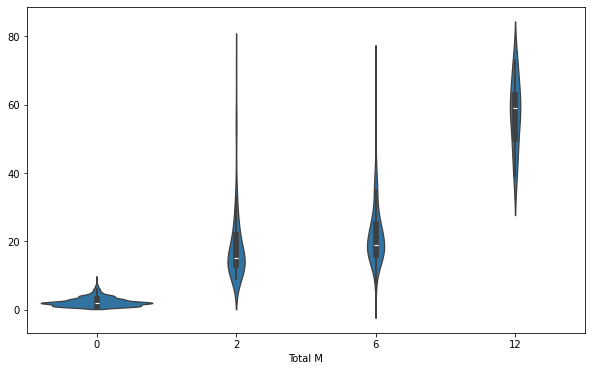

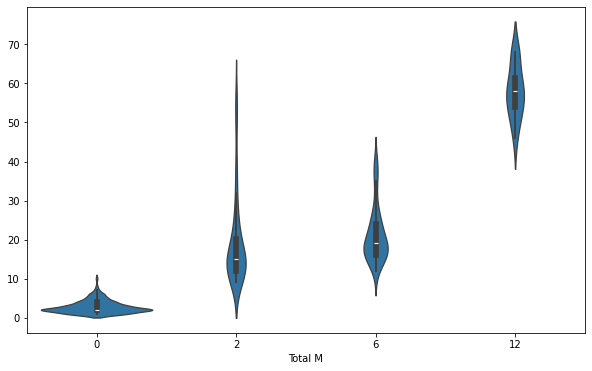

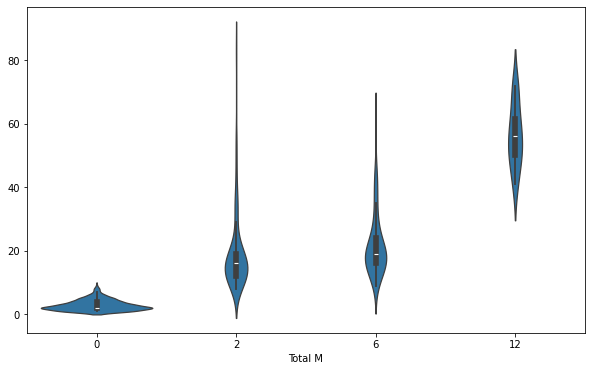

In [16]:
path = "/Users/csfloyd/Dropbox/Projects/GlycanAnalysis/Dirs/F_range"

vars = [0, 1, 2, 3, 4, 5]
M_list = []

for var in vars:
    with open(path + "/" + str(var) + "/SavedData.pkl", "rb") as file:
        M_0t1_list, M_1t0_list, M_0b1_list, r_n_list, sign_conditions_list = pickle.load(file)

    M_values = np.array(M_0t1_list) + np.array(M_1t0_list) + np.array(M_0b1_list)
    n_sign_conditions = np.array([len(s) for s in sign_conditions_list])

    plt.figure(figsize=(10,6))
    sns.violinplot(x=M_values, y=n_sign_conditions)
    plt.xlabel('Total M')

Sign conditions where M=12:
[16 17 10 14 15 12 11 14 14 10 11 16  8 25 18 11 19 49 14 12 14 17 18 18
 17 16 12 18 14 32 10 16 45 12 19 12 38 22 21 17 19 13 83 16 32 14  9 13
 12 13 35 13 56 16  9 12 16 34 36 18 29 11 20 21 11 35 11 14 15 11 17 18
 43 16 12 13 10 11 17 18 21 54 12 11 11  9 29 16 18 15 17 35 16 11 16 11
 24 12 17 15 21 22 16]
18.980582524271846


(array([47., 38.,  4.,  7.,  3.,  1.,  2.,  0.,  0.,  1.]),
 array([ 8. , 15.5, 23. , 30.5, 38. , 45.5, 53. , 60.5, 68. , 75.5, 83. ]),
 <BarContainer object of 10 artists>)

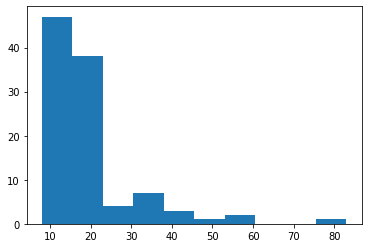

In [27]:
with open(path + "/" + str(5) + "/SavedData.pkl", "rb") as file:
        M_0t1_list, M_1t0_list, M_0b1_list, r_n_list, sign_conditions_list = pickle.load(file)

M_values = np.array(M_0t1_list) + np.array(M_1t0_list) + np.array(M_0b1_list)
n_sign_conditions = np.array([len(s) for s in sign_conditions_list])
n_sign_conditions_12 = n_sign_conditions[M_values == 2]
print("Sign conditions where M=12:")
print(n_sign_conditions_12)
print(np.mean(n_sign_conditions_12))
plt.hist(n_sign_conditions_12)

Text(0, 0.5, 'Number of sign conditions')

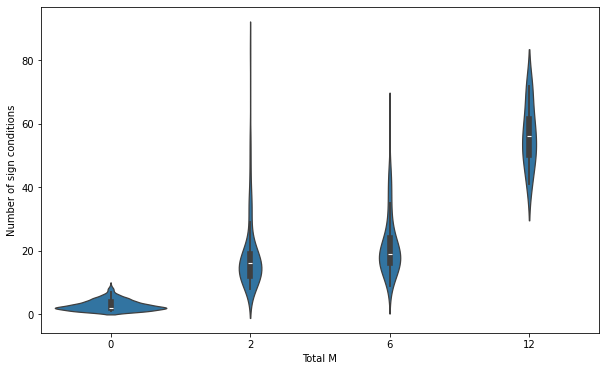

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

n_sign_conditions = np.array([len(s) for s in sign_conditions_list])
M_values = np.array(M_0t1_list) + np.array(M_1t0_list) + np.array(M_0b1_list)


plt.figure(figsize=(10,6))
sns.violinplot(x=M_values, y=n_sign_conditions)
plt.xlabel('Total M')

plt.ylabel('Number of sign conditions')

Text(0, 0.5, 'Number of sign conditions')

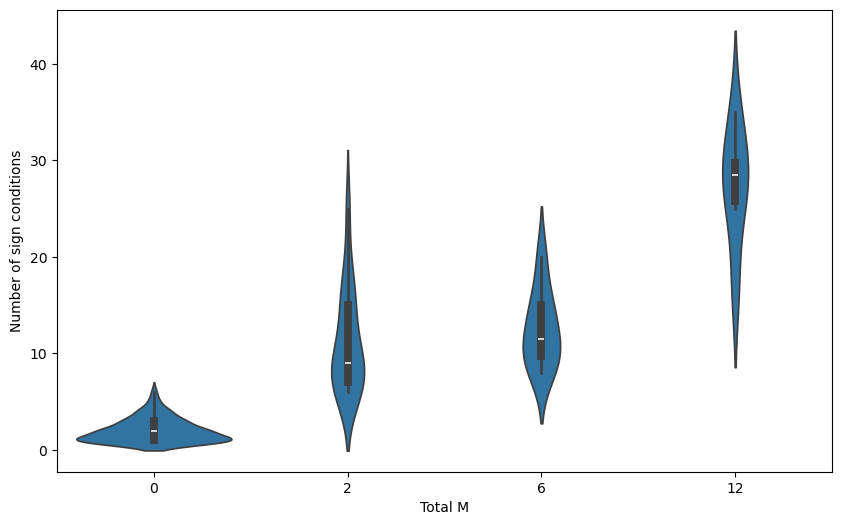

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

n_sign_conditions = np.array([len(s) for s in sign_conditions_list])
M_values = np.array(M_0t1_list) + np.array(M_1t0_list) + np.array(M_0b1_list)


plt.figure(figsize=(10,6))
sns.violinplot(x=M_values, y=n_sign_conditions)
plt.xlabel('Total M')

plt.ylabel('Number of sign conditions')

#plt.grid(True, alpha=0.3)

Text(0, 0.5, 'Number of sign conditions')

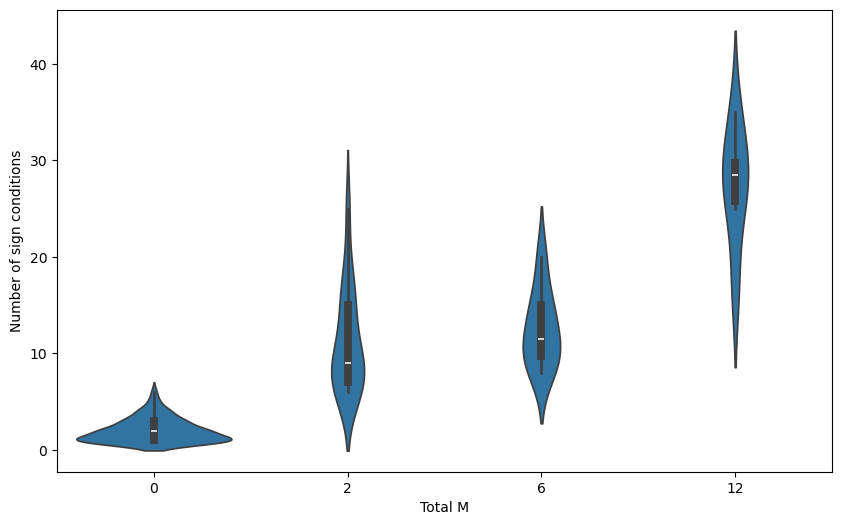

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

n_sign_conditions = np.array([len(s) for s in sign_conditions_list])
M_values = np.array(M_0t1_list) + np.array(M_1t0_list) + np.array(M_0b1_list)


plt.figure(figsize=(10,6))
sns.violinplot(x=M_values, y=n_sign_conditions)
plt.xlabel('Total M')

plt.ylabel('Number of sign conditions')

#plt.grid(True, alpha=0.3)